# Module 9: OLS of 1-year-ahead ROA

Regresses 1-year-ahead return on assets (`ni / at`, led one fiscal year) on current-year ratios (asset turnover, R&D intensity, operating cash flow to assets) plus 2-digit SIC industry dummies, using HC3 heteroskedasticity-robust standard errors.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from matplotlib import pyplot as plt

# Jupyter's kernel cwd is this notebook's own directory, not the repo
# root, so src.* isn't importable without this (unlike python -m src.xxx
# from the repo root, which puts the root on sys.path automatically).
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.models.ols import fit_ols
from src.schema import FundamentalsSchema

DATA_PATH = REPO_ROOT / "data" / "raw" / "fundamentals.parquet"
RESULTS_DIR = REPO_ROOT / "results" / "m9"

RATIO_FEATURES = ["asset_turnover", "rd_intensity", "cfo_to_at"]

## Load and validate

Loads the Module 8 fundamentals pull and runs it through `FundamentalsSchema` as a gate check. The schema's `Config.strict = "filter"` would silently drop `oancf`/`xrd`/`sich` (they aren't declared fields) if we used its returned frame directly, so we validate for its side effect (raises on failure) and keep working with the original, full-column frame.

In [2]:
df = pd.read_parquet(DATA_PATH)
FundamentalsSchema.validate(df, lazy=True)
print(f"{len(df)} rows loaded")
df.head()

7461 rows loaded


,gvkey,datadate,fyear,tic,conm,at,lt,revt,ni,oancf,xrd,sich
0,001045,2015-12-31,2015,AAL,AMERICAN AIRLINES GROUP INC,48415.0,42780.0,40990.0,7610.0,6249.0,<NA>,4512
1,001045,2016-12-31,2016,AAL,AMERICAN AIRLINES GROUP INC,51274.0,47489.0,40180.0,2676.0,6524.0,<NA>,4512
2,001045,2017-12-31,2017,AAL,AMERICAN AIRLINES GROUP INC,51396.0,47470.0,42207.0,1919.0,4744.0,<NA>,4512
3,001045,2018-12-31,2018,AAL,AMERICAN AIRLINES GROUP INC,60580.0,60749.0,44541.0,1412.0,3533.0,<NA>,4512
4,001045,2019-12-31,2019,AAL,AMERICAN AIRLINES GROUP INC,59995.0,60113.0,45768.0,1686.0,3815.0,<NA>,4512


## Construct target and features

- **Target**: 1-year-ahead ROA (`ni / at`, shifted forward one fiscal year within each firm).
- **Ratio features**: current-year asset turnover (`revt / at`), R&D intensity (`xrd / at`), operating cash flow to assets (`oancf / at`). Division by zero is replaced with `NaN` rather than left as `inf`, since real fundamentals data can have `at == 0` and `inf` would break the OLS fit.
- **Industry dummies**: bucketed to 2-digit SIC (major industry group) rather than the raw 4-digit `sich`. At 4-digit granularity, 8 of 241 codes have exactly one observation in the whole sample — a singleton-category dummy drives that row's leverage to exactly 1, and HC3 divides by `(1 - leverage)^2` in its sandwich formula, so leverage = 1 is a division by zero that crashes `.summary()` outright. 2-digit grouping (241 → 63 categories) eliminates every singleton.
- `drop_first=True` avoids the dummy trap: with an intercept already in the design matrix, including every category would make the dummy block collinear with the constant. statsmodels won't raise on this, but `.summary()` flags it as a multicollinearity footnote (see the fitted results below).

In [3]:
def build_dataset(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    df = df.sort_values(["gvkey", "fyear"]).copy()

    roa = df["ni"] / df["at"]
    df["target"] = roa.groupby(df["gvkey"]).shift(-1)

    df["asset_turnover"] = (df["revt"] / df["at"]).replace([np.inf, -np.inf], np.nan)
    # Compustat leaves xrd NULL for firms that don't disclose a separate
    # R&D line (not required unless material) — it does not code 0. That's
    # ~44% of the sample, concentrated in non-R&D sectors (utilities,
    # financials, retailers), so dropping those rows via dropna would bias
    # the regression toward R&D-heavy sectors. No disclosed R&D is treated
    # as economically zero R&D.
    df["rd_intensity"] = (df["xrd"].fillna(0) / df["at"]).replace([np.inf, -np.inf], np.nan)
    df["cfo_to_at"] = (df["oancf"] / df["at"]).replace([np.inf, -np.inf], np.nan)

    industry_group = df["sich"] // 100
    industry_dummies = pd.get_dummies(industry_group, prefix="sic2", drop_first=True).astype(float)

    df = pd.concat([df, industry_dummies], axis=1)
    features = RATIO_FEATURES + list(industry_dummies.columns)
    return df, features


df, features = build_dataset(df)
print(f"{len(features)} features ({len(features) - len(RATIO_FEATURES)} industry dummies)")

65 features (62 industry dummies)


## Fit and summarize

In [4]:
results = fit_ols(df, target="target", features=features)
print(results.summary())

fit_ols: dropped 766 of 7461 rows with NaN in target/features


                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.445
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     103.4
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:27:26   Log-Likelihood:                 9743.5
No. Observations:                6695   AIC:                        -1.936e+04
Df Residuals:                    6629   BIC:                        -1.891e+04
Df Model:                          65                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0022      0.004     -0.

## Diagnostic plots

statsmodels has no one-call helper for all four: residuals-vs-fitted and `sm.qqplot` are direct, but scale-location and leverage are hand-rolled from `results.get_influence()`.

Diagnostic plots written to /home/zhuwei/Projects/accy575/ACCY575-wrds-data-analysis/results/m9


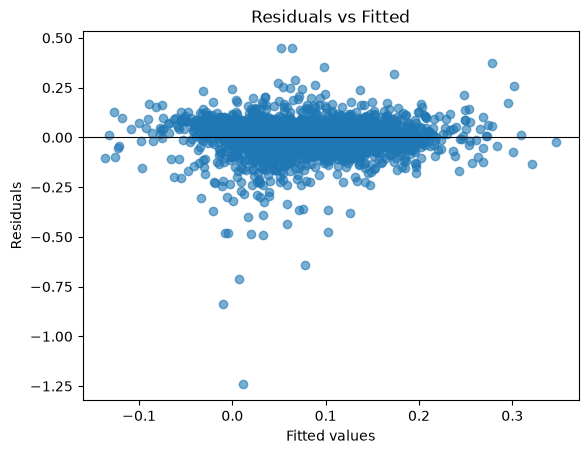

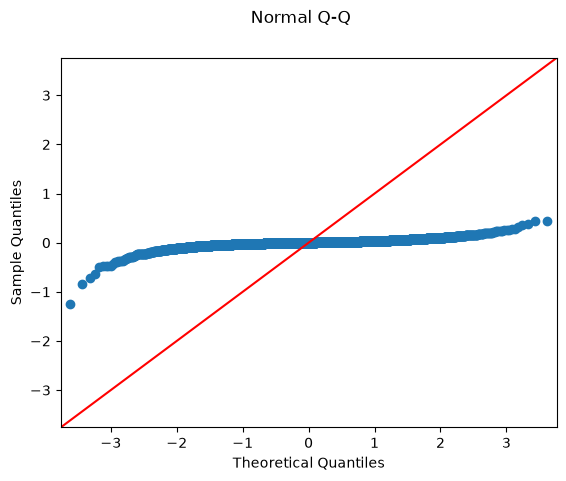

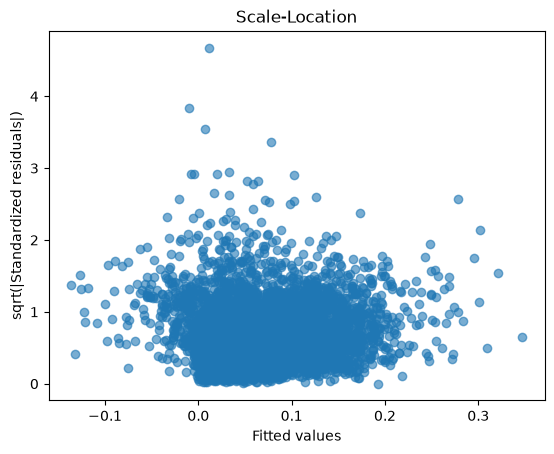

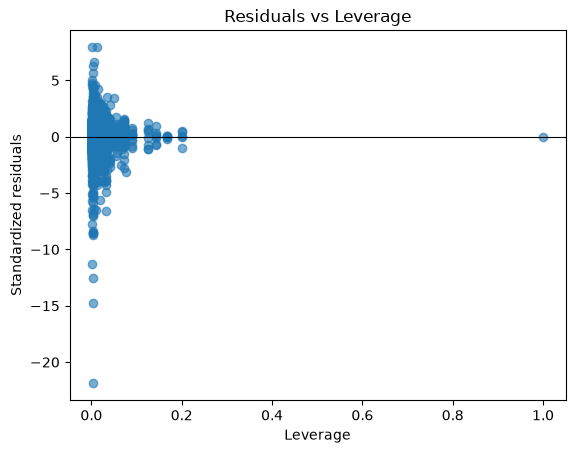

In [5]:
def save_diagnostics(results, out_dir: Path) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    fitted = results.fittedvalues
    resid = results.resid
    influence = results.get_influence()
    standardized_resid = influence.resid_studentized_internal
    leverage = influence.hat_matrix_diag

    fig, ax = plt.subplots()
    ax.scatter(fitted, resid, alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title("Residuals vs Fitted")
    fig.savefig(out_dir / "residuals_vs_fitted.png")

    fig = sm.qqplot(resid, line="45")
    fig.suptitle("Normal Q-Q")
    fig.savefig(out_dir / "qq_plot.png")

    fig, ax = plt.subplots()
    ax.scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("sqrt(|Standardized residuals|)")
    ax.set_title("Scale-Location")
    fig.savefig(out_dir / "scale_location.png")

    fig, ax = plt.subplots()
    ax.scatter(leverage, standardized_resid, alpha=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Leverage")
    ax.set_ylabel("Standardized residuals")
    ax.set_title("Residuals vs Leverage")
    fig.savefig(out_dir / "leverage.png")


save_diagnostics(results, RESULTS_DIR)
print(f"Diagnostic plots written to {RESULTS_DIR}")

## Robustness: excluding fiscal year 2020

Re-fits on the same panel with fyear == 2020 observations dropped (COVID-year features excluded as predictors; target construction is unaffected since leads were computed on the full panel before filtering).

In [6]:
results_ex2020 = fit_ols(df[df["fyear"] != 2020], target="target", features=features)

print(f"cfo_to_at, full sample:  {results.params['cfo_to_at']:.4f} (se={results.bse['cfo_to_at']:.4f})")
print(f"cfo_to_at, excl. 2020:   {results_ex2020.params['cfo_to_at']:.4f} (se={results_ex2020.bse['cfo_to_at']:.4f})")
print(f"difference:              {results_ex2020.params['cfo_to_at'] - results.params['cfo_to_at']:.4f}")

fit_ols: dropped 748 of 6964 rows with NaN in target/features
cfo_to_at, full sample:  0.6201 (se=0.0191)
cfo_to_at, excl. 2020:   0.6270 (se=0.0201)
difference:              0.0068


**The `cfo_to_at` coefficient is stable to excluding 2020** (0.620 → 0.627, well within one standard error), so the COVID year isn't driving that result.

## Robustness: excluding the financial/banking industry

Re-fits with SIC division H (Finance, Insurance, and Real Estate; `sich` 6000–6799) dropped, since firms in this sector have fundamentally different balance-sheet structures (e.g. `at` and `oancf` mean something different for a bank than a manufacturer).

In [7]:
is_financial = df["sich"].between(6000, 6799)
results_ex_financial = fit_ols(df[~is_financial], target="target", features=features)

print(f"cfo_to_at, full sample:   {results.params['cfo_to_at']:.4f} (se={results.bse['cfo_to_at']:.4f})")
print(f"cfo_to_at, excl. finance: {results_ex_financial.params['cfo_to_at']:.4f} (se={results_ex_financial.bse['cfo_to_at']:.4f})")
print(f"difference:               {results_ex_financial.params['cfo_to_at'] - results.params['cfo_to_at']:.4f}")

fit_ols: dropped 629 of 6007 rows with NaN in target/features


cfo_to_at, full sample:   0.6201 (se=0.0191)
cfo_to_at, excl. finance: 0.6072 (se=0.0211)
difference:               -0.0130


**The `cfo_to_at` coefficient is stable to excluding financials/banking** (0.620 → 0.607, well within one standard error), so the result isn't an artifact of that sector's different balance-sheet structure.

## Robustness: winsorizing continuous variables

Re-fits with the target and the three ratio features (not the industry dummies, which are binary) clipped to their 1st/99th percentile values, to check sensitivity to extreme outliers.

In [8]:
def winsorize(s: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    return s.clip(s.quantile(lower), s.quantile(upper))


df_winsorized = df.copy()
for col in ["target", *RATIO_FEATURES]:
    df_winsorized[col] = winsorize(df_winsorized[col])

results_winsorized = fit_ols(df_winsorized, target="target", features=features)

print(f"cfo_to_at, full sample: {results.params['cfo_to_at']:.4f} (se={results.bse['cfo_to_at']:.4f})")
print(f"cfo_to_at, winsorized:  {results_winsorized.params['cfo_to_at']:.4f} (se={results_winsorized.bse['cfo_to_at']:.4f})")
print(f"difference:             {results_winsorized.params['cfo_to_at'] - results.params['cfo_to_at']:.4f}")

fit_ols: dropped 766 of 7461 rows with NaN in target/features


cfo_to_at, full sample: 0.6201 (se=0.0191)
cfo_to_at, winsorized:  0.6137 (se=0.0151)
difference:             -0.0065


**The `cfo_to_at` coefficient is stable to winsorizing** (0.620 → 0.614, well within one standard error, with a tighter SE as expected from reduced outlier influence), so it isn't being driven by extreme values.